In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L1VzZXJzL2FsYWwvRGVza3RvcC9jb2RlL2NyYWJieW1ldHJpY3MvZG9jcy9hYmxhdGlvbnM='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/Users/alal/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/importlib/_bootstrap.py": 1743382022.7735002, "/Users/alal/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/importlib/_bootstrap_external.py": 1743382022.7737157, "/Users/alal/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/zipimport.py": 1743382022.8471594, "/Users/alal/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/codecs.py": 1743382022.716922, "/Users/alal/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/encodings/aliases.py": 1743382022.7266889, "/Users/alal/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/encodings/__init__.py": 1743382022.7262201, "/Users/alal/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/encodings/utf_8.py": 1743382022.7358487, "/Users/alal/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/abc.py": 1743382022.7091

In [2]:
from html import escape
import time

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display

import crabbymetrics as cm

np.set_printoptions(precision=4, suppress=True)


def html_table(headers, rows):
    parts = ["<table>", "<thead>", "<tr>"]
    parts.extend(f"<th>{escape(str(header))}</th>" for header in headers)
    parts.extend(["</tr>", "</thead>", "<tbody>"])
    for row in rows:
        parts.append("<tr>")
        parts.extend(f"<td>{cell}</td>" for cell in row)
        parts.append("</tr>")
    parts.extend(["</tbody>", "</table>"])
    return "".join(parts)

In [3]:
def run_ols_once(n, p, noise, multiple, seed):
    rng = np.random.default_rng(seed)
    x = rng.normal(size=(n, p))
    beta = rng.normal(size=p)
    intercept = 0.4
    y = intercept + x @ beta + noise * rng.normal(size=n)
    sketch_size = int(multiple * (p + 1))

    full = cm.OLS()
    t0 = time.perf_counter()
    full.fit(x, y)
    full_time = time.perf_counter() - t0
    full_summary = full.summary(vcov="vanilla")
    full_param = np.concatenate([[full_summary["intercept"]], full_summary["coef"]])

    sketch = cm.OLS()
    t0 = time.perf_counter()
    sketch.fit_sketch(x, y, sketch_size=sketch_size, seed=seed + 10_000)
    sketch_time = time.perf_counter() - t0
    sketch_summary = sketch.summary(vcov="vanilla")
    sketch_param = np.concatenate([[sketch_summary["intercept"]], sketch_summary["coef"]])

    x_test = rng.normal(size=(2000, p))
    full_pred = full.predict(x_test)
    sketch_pred = sketch.predict(x_test)

    return {
        "multiple": multiple,
        "sketch_size": sketch_size,
        "coef_rel_error": float(
            np.linalg.norm(sketch_param - full_param) / np.linalg.norm(full_param)
        ),
        "prediction_rmse_vs_full": float(np.sqrt(np.mean((sketch_pred - full_pred) ** 2))),
        "full_fit_seconds": full_time,
        "sketch_fit_seconds": sketch_time,
        "speedup": full_time / sketch_time if sketch_time > 0 else np.inf,
    }


ols_n = 20_000
ols_p = 40
ols_noise = 0.2
multiples = [2, 4, 8, 12, 16]
seeds = range(5)

ols_rows = [
    run_ols_once(ols_n, ols_p, ols_noise, multiple, seed)
    for multiple in multiples
    for seed in seeds
]
print("OLS replications:", len(ols_rows))
print("OLS design:", {"n": ols_n, "p": ols_p, "noise": ols_noise})

OLS replications: 25
OLS design: {'n': 20000, 'p': 40, 'noise': 0.2}


In [4]:
ols_summary = []
for multiple in multiples:
    block = [row for row in ols_rows if row["multiple"] == multiple]
    ols_summary.append(
        {
            "multiple": multiple,
            "sketch_size": block[0]["sketch_size"],
            "median_coef_rel_error": float(np.median([r["coef_rel_error"] for r in block])),
            "median_prediction_rmse_vs_full": float(
                np.median([r["prediction_rmse_vs_full"] for r in block])
            ),
            "median_speedup": float(np.median([r["speedup"] for r in block])),
        }
    )

ols_summary_rows = [
    [
        f"{entry['multiple']}x",
        entry["sketch_size"],
        f"{entry['median_coef_rel_error']:.4f}",
        f"{entry['median_prediction_rmse_vs_full']:.4f}",
        f"{entry['median_speedup']:.2f}x",
    ]
    for entry in ols_summary
]

display(
    HTML(
        html_table(
            [
                "Sketch multiple",
                "Sketch size",
                "Median coefficient relative error",
                "Median prediction RMSE vs full OLS",
                "Median speedup",
            ],
            ols_summary_rows,
        )
    )
)

Sketch multiple,Sketch size,Median coefficient relative error,Median prediction RMSE vs full OLS,Median speedup
2x,82,0.0312,0.2242,2.75x
4x,164,0.0188,0.1140,2.82x
8x,328,0.0106,0.0745,2.68x
12x,492,0.0086,0.0629,2.50x
16x,656,0.0083,0.0562,2.32x


In [5]:
def rbf_kernel(x, z, bandwidth):
    x_norm = np.sum(x * x, axis=1)[:, None]
    z_norm = np.sum(z * z, axis=1)[None, :]
    sqdist = np.maximum(x_norm + z_norm - 2.0 * x @ z.T, 0.0)
    return np.exp(-sqdist / bandwidth)


def ridge_on_features(phi_train, y_train, phi_test, penalty):
    gram = phi_train.T @ phi_train
    rhs = phi_train.T @ y_train
    coef = np.linalg.solve(gram + penalty * np.eye(gram.shape[0]), rhs)
    return phi_test @ coef


def run_kernel_once(n_train, n_test, n_features, bandwidth, penalty, components, seed):
    rng = np.random.default_rng(seed)
    x_train = rng.uniform(-3.0, 3.0, size=(n_train, n_features))
    x_test = rng.uniform(-3.0, 3.0, size=(n_test, n_features))

    def signal(x):
        return (
            np.sin(1.4 * x[:, 0])
            + 0.7 * np.cos(1.1 * x[:, 1] * x[:, 2])
            + 0.3 * x[:, 3] ** 2
            - 0.2 * x[:, 4]
        )

    f_train = signal(x_train)
    f_test = signal(x_test)
    y_train = f_train + 0.15 * rng.normal(size=n_train)

    t0 = time.perf_counter()
    k_train = rbf_kernel(x_train, x_train, bandwidth)
    k_test = rbf_kernel(x_test, x_train, bandwidth)
    alpha = np.linalg.solve(k_train + penalty * np.eye(n_train), y_train)
    full_pred = k_test @ alpha
    full_time = time.perf_counter() - t0

    out = []
    for method in ["Nyström", "Random Fourier"]:
        t0 = time.perf_counter()
        if method == "Nyström":
            basis = cm.NystromBasis(
                components,
                kernel="gaussian",
                bandwidth=bandwidth,
                ridge=1e-10,
                seed=seed + 30_000,
            )
        else:
            basis = cm.RandomFourierFeatures(
                components,
                bandwidth=bandwidth,
                seed=seed + 40_000,
            )
        phi_train = basis.fit_transform(x_train)
        phi_test = basis.transform(x_test)
        sketch_pred = ridge_on_features(phi_train, y_train, phi_test, penalty)
        sketch_time = time.perf_counter() - t0
        k_approx = phi_train @ phi_train.T

        out.append(
            {
                "method": method,
                "components": components,
                "kernel_rel_error": float(
                    np.linalg.norm(k_approx - k_train, ord="fro")
                    / np.linalg.norm(k_train, ord="fro")
                ),
                "rmse_vs_truth": float(np.sqrt(np.mean((sketch_pred - f_test) ** 2))),
                "rmse_vs_full_krr": float(np.sqrt(np.mean((sketch_pred - full_pred) ** 2))),
                "full_rmse_vs_truth": float(np.sqrt(np.mean((full_pred - f_test) ** 2))),
                "full_fit_seconds": full_time,
                "sketch_fit_seconds": sketch_time,
                "speedup": full_time / sketch_time if sketch_time > 0 else np.inf,
            }
        )
    return out


kernel_n_train = 1_200
kernel_n_test = 600
kernel_n_features = 5
kernel_bandwidth = 8.0
kernel_penalty = 1.0
component_grid = [50, 100, 200, 400]
kernel_seeds = range(3)

kernel_rows = [
    row
    for components in component_grid
    for seed in kernel_seeds
    for row in run_kernel_once(
        kernel_n_train,
        kernel_n_test,
        kernel_n_features,
        kernel_bandwidth,
        kernel_penalty,
        components,
        seed,
    )
]
print("Kernel replications:", len(kernel_rows))
print(
    "Kernel design:",
    {
        "n_train": kernel_n_train,
        "n_test": kernel_n_test,
        "p": kernel_n_features,
        "bandwidth": kernel_bandwidth,
        "penalty": kernel_penalty,
    },
)

Kernel replications: 24
Kernel design: {'n_train': 1200, 'n_test': 600, 'p': 5, 'bandwidth': 8.0, 'penalty': 1.0}


In [6]:
kernel_summary = []
for method in ["Nyström", "Random Fourier"]:
    for components in component_grid:
        block = [
            row
            for row in kernel_rows
            if row["method"] == method and row["components"] == components
        ]
        kernel_summary.append(
            {
                "method": method,
                "components": components,
                "median_kernel_rel_error": float(
                    np.median([r["kernel_rel_error"] for r in block])
                ),
                "median_rmse_vs_truth": float(np.median([r["rmse_vs_truth"] for r in block])),
                "median_rmse_vs_full_krr": float(
                    np.median([r["rmse_vs_full_krr"] for r in block])
                ),
                "median_speedup": float(np.median([r["speedup"] for r in block])),
                "median_full_rmse_vs_truth": float(
                    np.median([r["full_rmse_vs_truth"] for r in block])
                ),
            }
        )

kernel_summary_rows = [
    [
        entry["method"],
        entry["components"],
        f"{entry['median_kernel_rel_error']:.4f}",
        f"{entry['median_rmse_vs_truth']:.4f}",
        f"{entry['median_rmse_vs_full_krr']:.4f}",
        f"{entry['median_speedup']:.2f}x",
    ]
    for entry in kernel_summary
]

display(
    HTML(
        html_table(
            [
                "Approximation",
                "Features",
                "Median kernel relative error",
                "Median test RMSE vs truth",
                "Median test RMSE vs full KRR",
                "Median full/sketch time",
            ],
            kernel_summary_rows,
        )
    )
)

full_rmse = kernel_summary[0]["median_full_rmse_vs_truth"]
print(f"Median full-kernel KRR test RMSE vs truth: {full_rmse:.4f}")

Approximation,Features,Median kernel relative error,Median test RMSE vs truth,Median test RMSE vs full KRR,Median full/sketch time
Nyström,50,0.3137,0.9244,0.5892,15.11x
Nyström,100,0.1577,0.7547,0.3639,5.59x
Nyström,200,0.0694,0.6203,0.1511,1.51x
Nyström,400,0.0200,0.5826,0.0552,0.30x
Random Fourier,50,0.8513,0.9714,0.6732,17.37x
Random Fourier,100,0.6446,0.8057,0.4599,8.58x
Random Fourier,200,0.4394,0.7697,0.3668,4.18x
Random Fourier,400,0.2927,0.6285,0.2293,1.92x


Median full-kernel KRR test RMSE vs truth: 0.5659


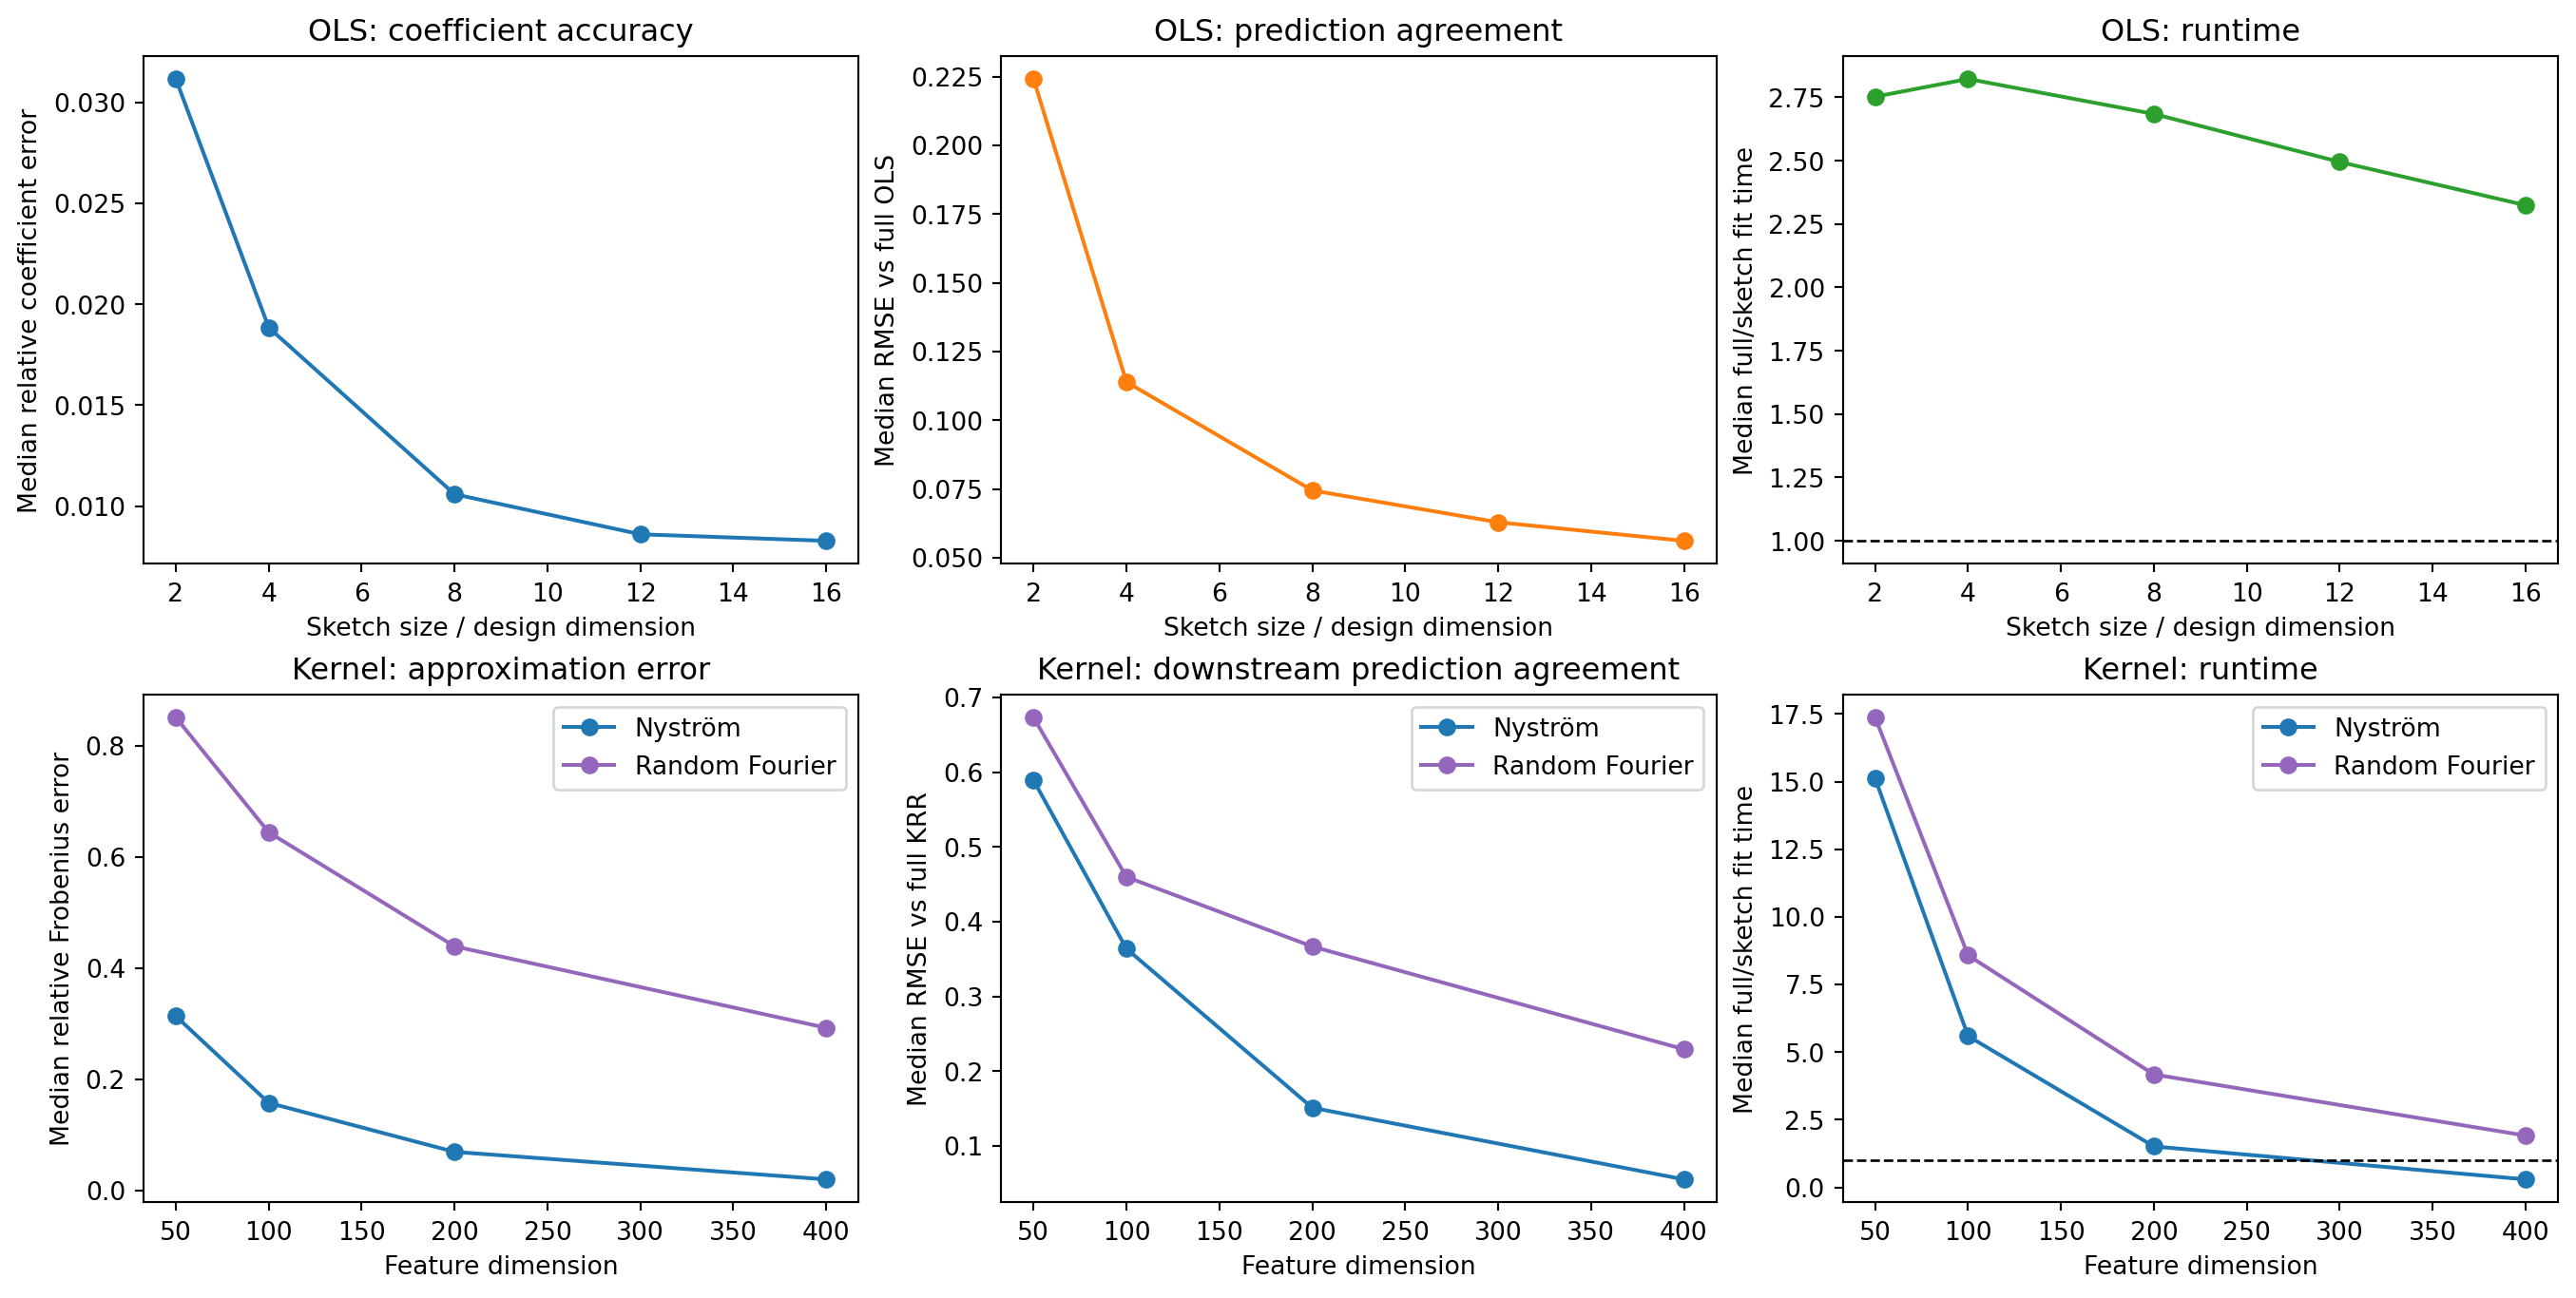

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)

ols_x = np.array([entry["multiple"] for entry in ols_summary])
axes[0, 0].plot(ols_x, [entry["median_coef_rel_error"] for entry in ols_summary], marker="o")
axes[0, 0].set_xlabel("Sketch size / design dimension")
axes[0, 0].set_ylabel("Median relative coefficient error")
axes[0, 0].set_title("OLS: coefficient accuracy")

axes[0, 1].plot(
    ols_x,
    [entry["median_prediction_rmse_vs_full"] for entry in ols_summary],
    marker="o",
    color="tab:orange",
)
axes[0, 1].set_xlabel("Sketch size / design dimension")
axes[0, 1].set_ylabel("Median RMSE vs full OLS")
axes[0, 1].set_title("OLS: prediction agreement")

axes[0, 2].plot(ols_x, [entry["median_speedup"] for entry in ols_summary], marker="o", color="tab:green")
axes[0, 2].axhline(1.0, color="black", linestyle="--", linewidth=1)
axes[0, 2].set_xlabel("Sketch size / design dimension")
axes[0, 2].set_ylabel("Median full/sketch fit time")
axes[0, 2].set_title("OLS: runtime")

for method, color in [("Nyström", "tab:blue"), ("Random Fourier", "tab:purple")]:
    block = [entry for entry in kernel_summary if entry["method"] == method]
    x_axis = np.array([entry["components"] for entry in block])
    axes[1, 0].plot(
        x_axis,
        [entry["median_kernel_rel_error"] for entry in block],
        marker="o",
        label=method,
        color=color,
    )
    axes[1, 1].plot(
        x_axis,
        [entry["median_rmse_vs_full_krr"] for entry in block],
        marker="o",
        label=method,
        color=color,
    )
    axes[1, 2].plot(
        x_axis,
        [entry["median_speedup"] for entry in block],
        marker="o",
        label=method,
        color=color,
    )

axes[1, 0].set_xlabel("Feature dimension")
axes[1, 0].set_ylabel("Median relative Frobenius error")
axes[1, 0].set_title("Kernel: approximation error")
axes[1, 0].legend()

axes[1, 1].set_xlabel("Feature dimension")
axes[1, 1].set_ylabel("Median RMSE vs full KRR")
axes[1, 1].set_title("Kernel: downstream prediction agreement")
axes[1, 1].legend()

axes[1, 2].axhline(1.0, color="black", linestyle="--", linewidth=1)
axes[1, 2].set_xlabel("Feature dimension")
axes[1, 2].set_ylabel("Median full/sketch fit time")
axes[1, 2].set_title("Kernel: runtime")
axes[1, 2].legend()

plt.show()